In [1]:
import pandas as pd
df = pd.read_csv("hf://datasets/AmaanP314/youtube-comment-sentiment/youtube-comments-sentiment.csv")


/home/bashar/anaconda3/envs/mlops/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Inspect the data

In [3]:
df.head()


,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,2025-01-15 00:54:55,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,2025-01-13 23:51:46,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,2020-07-06 13:18:16,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video.\n\nI don't underst...,Neutral,0,1,2024-09-18 12:04:12,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,-hV6aeyPHPA,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people.\nThis is how ...,Positive,3,1,2025-01-10 19:39:03,US,2


In [5]:
df_reduced = df[['CommentText','Sentiment']]

In [ ]:
df_reduced.dropna(inplace=True)


/tmp/ipykernel_227686/446470601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced.dropna(inplace=True)


In [111]:
df_reduced.drop_duplicates(inplace=True)

In [27]:
sentiment_dict = {'Positive':1,'Neutral':0,'Negative':-1}

In [ ]:
df_reduced['Sentiment_index'] =  pd.DataFrame.apply(df_reduced, lambda v: sentiment_dict[v['Sentiment']], axis=1)

In [40]:
df_reduced.groupby('Sentiment').count()

,CommentText,Sentiment_index
Sentiment,,
Negative,346075,346075
Neutral,342833,342833
Positive,343317,343317


In [110]:
print(df_reduced.sample(random_state=112231223)['CommentText'].values[0])

"Don't Lose Your Child Here" is wild.


In [114]:
df_reduced[df_reduced['CommentText'].str.strip() == '']
df_reduced = df_reduced[~(df_reduced['CommentText'].str.strip() == '')]

In [116]:
df_reduced['CommentText'] = df_reduced['CommentText'].str.lower()

/tmp/ipykernel_227686/813863181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced['CommentText'] = df_reduced['CommentText'].str.lower()


In [119]:
df_reduced[df_reduced['CommentText'].str.startswith(' ') | df_reduced['CommentText'].str.endswith(' ')]

,CommentText,Sentiment,Sentiment_index
1054,ayo 1:02,Neutral,0
2266,"""one of the most difficult places to reach wi...",Negative,-1
4000,finally 4k video,Neutral,0
4087,i genuinely feel sorry for george,Negative,-1
5175,china has entered the comment section,Neutral,0
...,...,...,...
1013012,that was an incredible comeback. that was a gr...,Positive,1
1016686,the dye got to his pea brain.,Negative,-1
1018739,they used frog dna to fill in the missing gaps...,Neutral,0
1021856,"""on the planet...maaaarrsss"" 😂😂",Neutral,0


In [120]:
df_reduced['CommentText'] = df_reduced['CommentText'].str.strip()

/tmp/ipykernel_227686/2956724770.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced['CommentText'] = df_reduced['CommentText'].str.strip()


In [ ]:
df_reduced[df_reduced['CommentText'].str]

,CommentText,Sentiment,Sentiment_index


In [122]:
url_pattern = r"""https?://[^\s<>"']+"""
text_with_url = df_reduced[df_reduced['CommentText'].str.contains(url_pattern, regex=True)]

In [ ]:
df_reduced = df_reduced[~df_reduced['CommentText'].str.contains(url_pattern, regex=True)]

In [126]:
df_reduced[df_reduced['CommentText'].str.contains(url_pattern, regex=True)].sum()


CommentText        0
Sentiment          0
Sentiment_index    0
dtype: object

In [127]:
df_reduced[df_reduced['CommentText'].str.contains('\n')]

,CommentText,Sentiment,Sentiment_index
3,thanks for the great video.\n\ni don't underst...,Neutral,0
4,good person helping good people.\nthis is how ...,Positive,1
14,yeah i just found out he’s the best pick becau...,Neutral,0
39,tiktok was a school for all they choosen to wa...,Positive,1
46,joe: bring stacy on\nstaffers: why?\njoe: just...,Neutral,0
...,...,...,...
1032171,muskets up: it’s the fascist vs fascist duel. ...,Neutral,0
1032180,denmark here ... denmark have so far pledged o...,Positive,1
1032203,"kyle. it is exactly how you described, “burn t...",Negative,-1
1032209,great class.\neven though it was 8 hours long....,Positive,1


In [128]:
df_reduced['CommentText'] = df_reduced['CommentText'].str.replace('\n', '')
df_reduced[df_reduced['CommentText'].str.contains('\n')]

/tmp/ipykernel_227686/1025470133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced['CommentText'] = df_reduced['CommentText'].str.replace('\n', '')


,CommentText,Sentiment,Sentiment_index


## EDA

<Axes: >

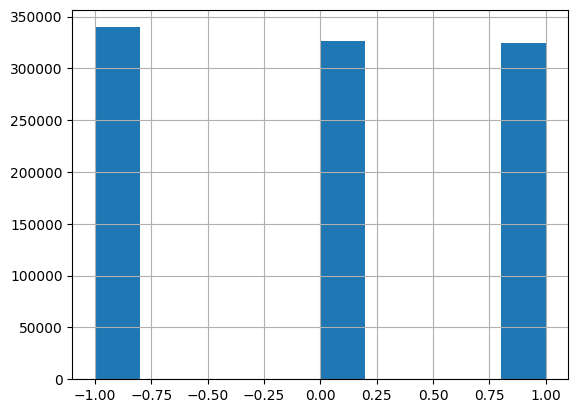

In [ ]:
import matplotlib.pyplot as plt
df_reduced['Sentiment_index'].hist()

In [139]:
df_reduced['WordCount'] = df_reduced['CommentText'].apply(lambda v : len(v.split()))

/tmp/ipykernel_227686/3384996336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced['WordCount'] = df_reduced['CommentText'].apply(lambda v : len(v.split()))


In [140]:
df_reduced['WordCount'].describe()

count    990344.000000
mean         19.676768
std          29.566693
min           1.000000
25%           7.000000
50%          12.000000
75%          23.000000
max        1796.000000
Name: WordCount, dtype: float64

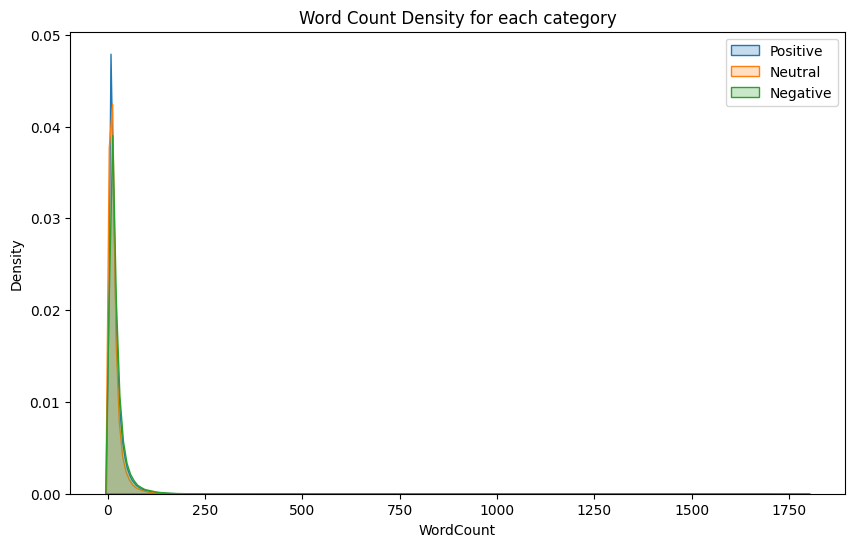

In [148]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(df_reduced[df_reduced['Sentiment_index'] == 1]['WordCount'], label='Positive', fill=True)
sns.kdeplot(df_reduced[df_reduced['Sentiment_index'] == 0]['WordCount'], label='Neutral', fill=True)
sns.kdeplot(df_reduced[df_reduced['Sentiment_index'] == -1]['WordCount'], label='Negative', fill=True)

plt.legend()


plt.title('Word Count Density for each category')
plt.show()

In [149]:
!pip install nltk

In [155]:
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

/home/bashar/anaconda3/envs/mlops/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/bashar/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to /home/bashar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [157]:
len(stop_words)

198

In [166]:
df = df_reduced[['CommentText','Sentiment_index','WordCount']]

In [167]:
df['NumStopWords'] = df['CommentText'].apply(lambda v: len([word for word in v.split() if word in stop_words]))

/tmp/ipykernel_227686/908810957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NumStopWords'] = df['CommentText'].apply(lambda v: len([word for word in v.split() if word in stop_words]))


In [171]:
df.sample(5)

,CommentText,Sentiment_index,WordCount,NumStopWords
67947,my dad is in the army that is what a real sold...,1,14,10
531178,so far the best node.js tutorial for beginners...,1,28,11
713704,how is nobody aware that this is an ai social ...,-1,13,7
975335,these types of videos make my brain feel like ...,-1,10,3
445979,"hi harry, firstly, i want to express my gratit...",0,78,33


In [1]:

plt.figure(figsize=(10,6))

sns.kdeplot(df_reduced[df_reduced['Sentiment_index'] == 1]['NumStopWords'], label='Positive', fill=True)
sns.kdeplot(df_reduced[df_reduced['Sentiment_index'] == 0]['NumStopWords'], label='Neutral', fill=True)
sns.kdeplot(df_reduced[df_reduced['Sentiment_index'] == -1]['NumStopWords'], label='Negative', fill=True)

plt.legend()


plt.title('Word Count Density for each category')
plt.show()

NameError: name 'plt' is not defined

In [186]:
### Get the top 25 used stop words:
from collections import Counter

counter = Counter()

all_stop_words = [word for comments in df['CommentText'] for word in comments.split() if word in stop_words]
most_common_stop_words = Counter(all_stop_words).most_common(25)


In [187]:
most_common_stop_words_df = pd.DataFrame(most_common_stop_words, columns=['StopWord','Frequency'])

/tmp/ipykernel_227686/4042167236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(most_common_stop_words_df, x ='Frequency', y='StopWord', palette='viridis')


Text(0.5, 1.0, 'Most 25 common stop words in the dataset ')

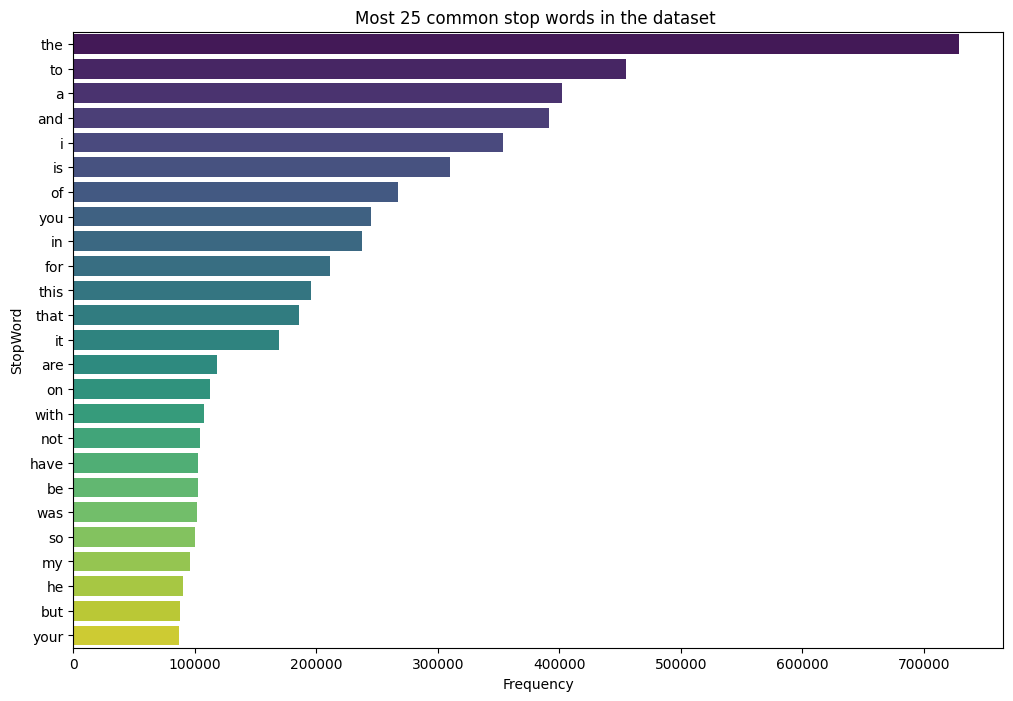

In [198]:
plt.figure(figsize=(12,8))
sns.barplot(most_common_stop_words_df, x ='Frequency', y='StopWord', palette='viridis')
plt.title('Most 25 common stop words in the dataset ')

In [202]:
df['NumChars'] = df['CommentText'].apply(len)
df.sample()

/tmp/ipykernel_227686/2273904634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NumChars'] = df['CommentText'].apply(len)


,CommentText,Sentiment_index,WordCount,NumStopWords,NumChars
176106,"don't mind me, i'm just here for the ""this cup...",0,13,7,72


In [204]:
df['NumChars'].describe()

count    990344.000000
mean        110.042437
std         175.878567
min           1.000000
25%          36.000000
50%          67.000000
75%         124.000000
max        9997.000000
Name: NumChars, dtype: float64

In [218]:
char_vocab = set(''.join(df['CommentText']))

In [219]:
char_vocab

{'\t',
 '\r',
 ' ',
 '!',
 ',',
 '.',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '?',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '\x85',
 '\xa0',
 '\u2003',
 '\u2006',
 '\u2009',
 '\u200a',
 '\u2028',
 '\u202f',
 '\u205f',
 '\u3000'}

In [214]:
df['NumPunctuationChars'] = df['CommentText'].apply(lambda x : sum([1 for char in x if char in './~?[]{}-():;"\'\\']))

In [215]:
df.sample(5)

,CommentText,Sentiment_index,WordCount,NumStopWords,NumChars,NumPunctuationChars
979425,"this is basically just shader math, you should...",0,42,17,223,5
924670,is it me or are the trees still green?,0,9,6,38,1
951382,germany wali 😂 diljeet smile give hint 😂,0,8,0,40,0
521528,being an officer in texas i can say that most ...,0,42,22,199,4
377230,"amazing solution to sorting, so easy 🤦🏻‍♂️",-1,7,2,42,0


In [216]:
import re 

df['CommentText'] = df['CommentText'].apply(lambda x : re.sub(r'[^A-Za-z0-9\s!?.,]','', str(x)))

In [217]:

df['CommentText']

0                            anyone know what movie this is?
1          the fact theyre holding each other back while ...
2                                waiting next video will be?
3          thanks for the great video.i dont understand w...
4          good person helping good people.this is how it...
                                 ...                        
1032219    me here just to read peoples comments about th...
1032220    any recommendations for how to build on top of...
1032221              act foolishly, receive foolish rewards.
1032222    i think many people would like to know the mod...
1032224                                         why no rust?
Name: CommentText, Length: 990344, dtype: object

In [223]:
stop_words = set(stopwords.words('english')) - {'but','not','however','no','yet'}

df['CommentText'] = df['CommentText'].apply(lambda x : ' '.join([word for word in x.split() if word not in stop_words]))

In [239]:
from nltk import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
df['CommentText'] = df['CommentText'].apply(lambda x : ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

In [3]:
import numpy as np

x = np.array([[1,2,3]])
np.save('test.npy',x)